In [244]:
import pandas as pd
from matplotlib import pyplot as plt

In [263]:
# spy_alpha = pd.read_csv('../outputs/volatility_forecast_2_monte_carlo/SPY_Analysis_alphas_all_runs.csv', index_col=0, parse_dates=True)
spy_alpha = pd.read_csv('../outputs/signature_volatility_forecast/spy_fixed_split_all_alphas.csv', index_col=0, parse_dates=True)

In [248]:
spy_preds = pd.read_csv('../outputs/volatility_forecast_2_monte_carlo/SPY_Analysis_predictions_all_runs.csv', index_col=0, parse_dates=True)

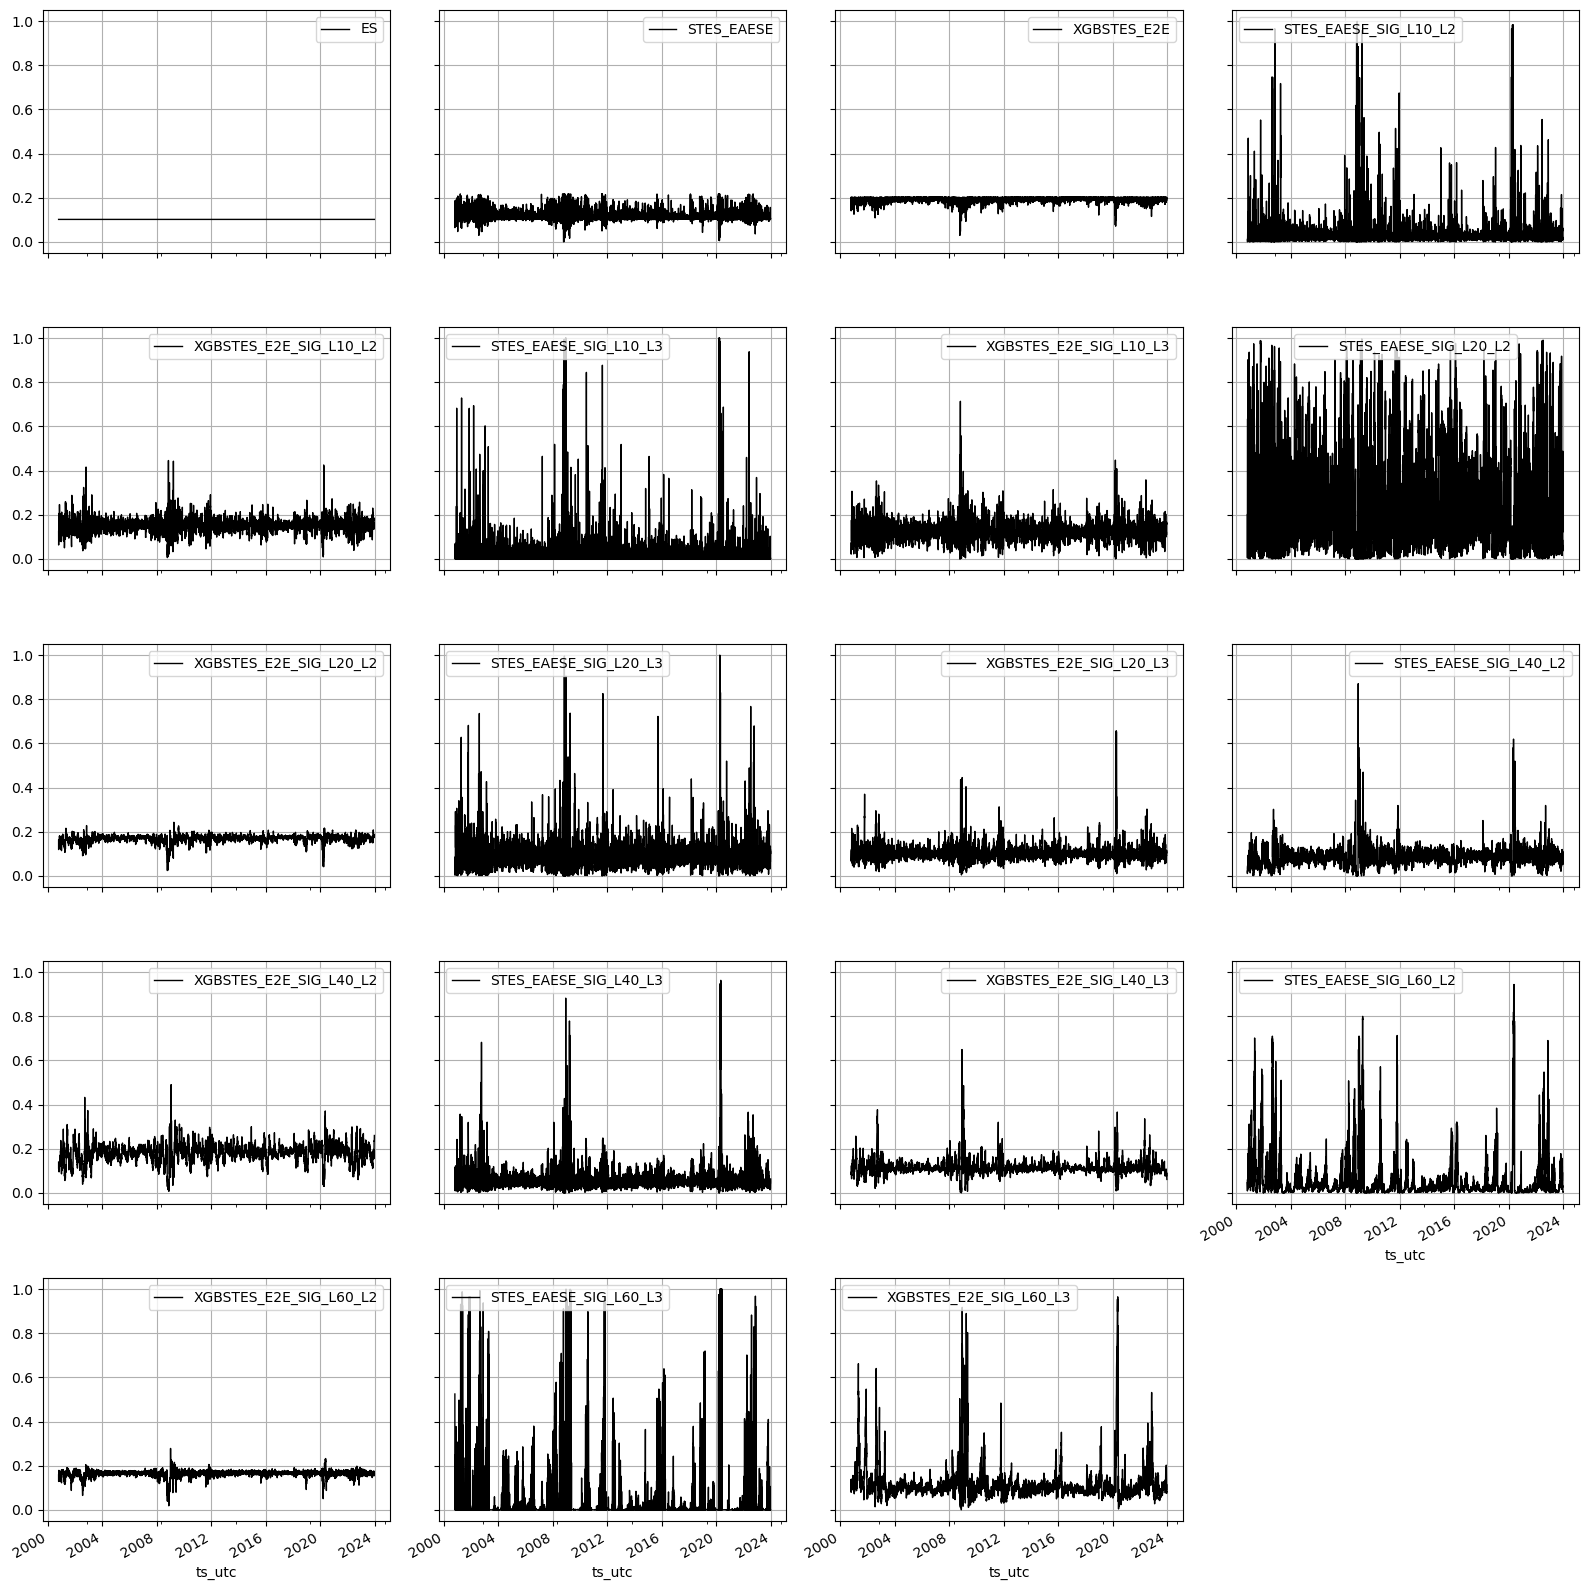

In [264]:
spy_alpha.plot(subplots=True, layout=(5, 4), figsize=(16, 16), sharex=True, sharey=True, color='k', lw=1, grid=True);
plt.tight_layout()
plt.savefig('../outputs/signature_volatility_forecast/alphas_comp.png')

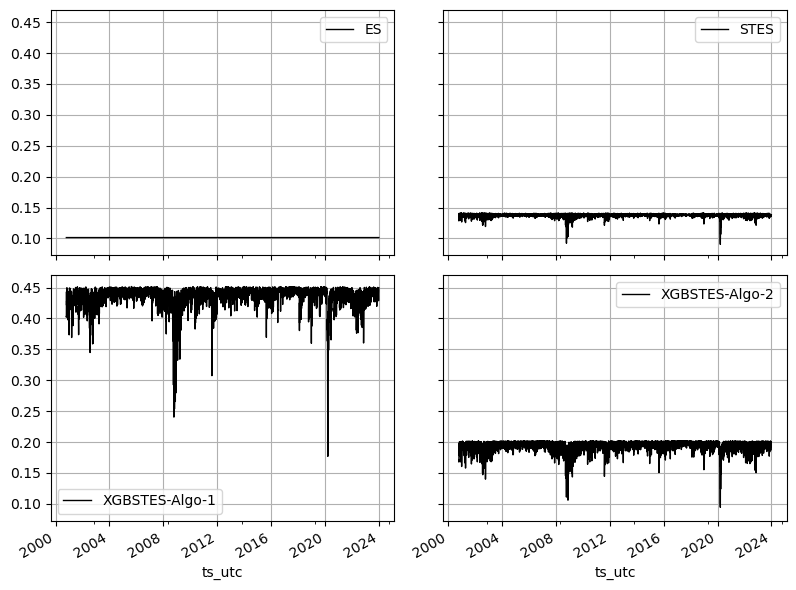

In [254]:
(
    spy_alpha
    .rename(columns={'ES_run_42': 'ES', 'STES_run_42': 'STES', 'XGBSTES_Alt_run_42': 'XGBSTES-Algo-1', 'XGBSTES_E2E_run_42': 'XGBSTES-Algo-2'})
    .rolling(window=2).mean()
).plot(subplots=True, figsize=(8, 6), layout=(2,2), sharex=True, sharey=True, color='k', lw=1, grid=True)
plt.tight_layout()
plt.savefig('../outputs/volatility_forecast_2_monte_carlo/alpha_comp.png')


In [210]:
from scipy.special import expit

In [212]:
expit(spy_alpha['XGBSTES_Alt_run_42'])

ts_utc
2000-10-18 16:00:00+00:00    0.591621
2000-10-19 16:00:00+00:00    0.543822
2000-10-20 16:00:00+00:00    0.639050
2000-10-23 16:00:00+00:00    0.626185
2000-10-24 16:00:00+00:00    0.597647
                               ...   
2023-12-21 16:00:00+00:00    0.603040
2023-12-22 16:00:00+00:00    0.610826
2023-12-26 16:00:00+00:00    0.639050
2023-12-27 16:00:00+00:00    0.622864
2023-12-28 16:00:00+00:00    0.590181
Name: XGBSTES_Alt_run_42, Length: 5835, dtype: float64

In [265]:
import numpy as np
from sktime.transformations.panel.signature_based import SignatureTransformer

# 1 channel, 5 timepoints, 2 samples
X = np.random.randn(2, 1, 5)

sig = SignatureTransformer(
    augmentation_list=["cumsum", "basepoint", "addtime", "leadlag"],
    depth=2,
    window_name="global",
    rescaling="post",          # triggers mismatch with logsignature
    sig_tfm="logsignature",
    backend="esig",
)

sig.fit_transform(X)

/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


ValueError: A path with 4 channels to depth 2 should yield a signature with 20 features. Input signature has 10 features which is inconsistent.

In [266]:
from sktime import show_versions; show_versions()


System:
    python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
executable: /Users/steveyang/miniforge3/envs/py312/bin/python
   machine: macOS-26.1-arm64-arm-64bit

Python dependencies:
          pip: 23.3.1
       sktime: 0.40.1
      sklearn: 1.7.2
       skbase: 0.13.0
        numpy: 2.3.5
        scipy: 1.16.3
       pandas: 2.3.3
   matplotlib: 3.10.8
       joblib: 1.5.2
huggingface-hub: None
        numba: None
     pmdarima: None
pytorch-forecasting: None
   skforecast: None
        skpro: None
statsforecast: None
  statsmodels: 0.14.6
 transformers: None
      tsfresh: None
      tslearn: None
        torch: 2.11.0.dev20260101
   tensorflow: None


In [268]:
SignatureTransformer(depth=2, window_name="global", rescaling="post", sig_tfm="logsignature", backend="esig").fit_transform(X)

ValueError: A path with 2 channels to depth 2 should yield a signature with 6 features. Input signature has 3 features which is inconsistent.